In [1]:
# Cell 1 — Install required libraries
import sys
!{sys.executable} -m pip install xgboost scikit-learn --quiet
print('All libraries installed ✅')

All libraries installed ✅



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import pickle

print('All imports successful ✅')

All imports successful ✅


In [3]:
# Cell 3 — Load train/test splits from Week 2
path = 'C:/Users/Lenovo/Desktop/FoodDemand/'

X_train = pd.read_csv(path + 'X_train.csv')
X_test  = pd.read_csv(path + 'X_test.csv')
y_train = pd.read_csv(path + 'y_train.csv').squeeze()
y_test  = pd.read_csv(path + 'y_test.csv').squeeze()

print('Data loaded successfully ✅')
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape  : {y_test.shape}')
print(f'\nFeatures ({len(X_train.columns)}):')
print(X_train.columns.tolist())

Data loaded successfully ✅
X_train shape : (345824, 20)
X_test shape  : (82027, 20)
y_train shape : (345824,)
y_test shape  : (82027,)

Features (20):
['week', 'week_in_year', 'month', 'quarter', 'is_weekend', 'is_holiday', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'center_id', 'meal_id', 'op_area', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4']


In [4]:
# Cell 4 — Metric helper functions
def evaluate(name, y_true, y_pred):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    rmsle = np.sqrt(np.mean((np.log1p(np.clip(y_pred,0,None)) - np.log1p(np.clip(y_true,0,None)))**2))
    print(f'  RMSE  : {rmse:>10.2f}')
    print(f'  MAE   : {mae:>10.2f}')
    print(f'  RMSLE : {rmsle:>10.4f}')
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'RMSLE': rmsle}

results = []  # store all model results for comparison
print('Helper functions ready ✅')

Helper functions ready ✅


In [5]:
# Cell 5 — BASELINE: Linear Regression
print('=' * 45)
print('MODEL 1: Linear Regression (Baseline)')
print('=' * 45)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_train = np.clip(lr_model.predict(X_train), 0, None)
lr_pred_test  = np.clip(lr_model.predict(X_test),  0, None)

print('Train metrics:')
evaluate('Linear Regression - Train', y_train, lr_pred_train)
print('Test metrics:')
res = evaluate('Linear Regression', y_test, lr_pred_test)
results.append(res)
print('Linear Regression done ✅')

MODEL 1: Linear Regression (Baseline)
Train metrics:
  RMSE  :     230.35
  MAE   :     104.11
  RMSLE :     1.1330
Test metrics:
  RMSE  :     211.86
  MAE   :      92.01
  RMSLE :     1.0480
Linear Regression done ✅


In [6]:
# Cell 6 — Time-Series Cross Validation setup
# TimeSeriesSplit ensures NO data leakage — future data never used to train
tscv = TimeSeriesSplit(n_splits=5)

print('Time-Series Cross Validation Setup')
print(f'Number of splits : 5')
print(f'Method           : TimeSeriesSplit (no data leakage)')
print()
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f'Fold {fold+1}: Train rows = {len(train_idx):>6} | Val rows = {len(val_idx):>6}')
print()
print('Note: Each fold trains on past data and validates on future data only ✅')

Time-Series Cross Validation Setup
Number of splits : 5
Method           : TimeSeriesSplit (no data leakage)

Fold 1: Train rows =  57639 | Val rows =  57637
Fold 2: Train rows = 115276 | Val rows =  57637
Fold 3: Train rows = 172913 | Val rows =  57637
Fold 4: Train rows = 230550 | Val rows =  57637
Fold 5: Train rows = 288187 | Val rows =  57637

Note: Each fold trains on past data and validates on future data only ✅


In [8]:
# Cell 7 — Random Forest with TimeSeriesSplit CV
print('=' * 45)
print('MODEL 2: Random Forest Regressor')
print('=' * 45)
print('Running Time-Series Cross Validation...')

rf_cv_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    pred = np.clip(rf.predict(X_val), 0, None)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    rf_cv_scores.append(rmse)
    print(f'  Fold {fold+1} RMSE: {rmse:.2f}')

print(f'\nCV Mean RMSE : {np.mean(rf_cv_scores):.2f}')
print(f'CV Std  RMSE : {np.std(rf_cv_scores):.2f}')

# Train final RF on full training data
print('\nTraining final Random Forest on full train set...')
rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
rf_pred_test = np.clip(rf_final.predict(X_test), 0, None)

print('Test metrics:')
res = evaluate('Random Forest', y_test, rf_pred_test)
results.append(res)
print('Random Forest done ✅')

MODEL 2: Random Forest Regressor
Running Time-Series Cross Validation...
  Fold 1 RMSE: 187.90
  Fold 2 RMSE: 137.23
  Fold 3 RMSE: 156.37
  Fold 4 RMSE: 175.07
  Fold 5 RMSE: 165.29

CV Mean RMSE : 164.37
CV Std  RMSE : 17.14

Training final Random Forest on full train set...
Test metrics:
  RMSE  :     170.25
  MAE   :      74.04
  RMSLE :     0.5387
Random Forest done ✅


In [9]:
# Cell 8 — XGBoost with TimeSeriesSplit CV + Hyperparameter Tuning
print('=' * 45)
print('MODEL 3: XGBoost Regressor')
print('=' * 45)
print('Running Time-Series Cross Validation with hyperparameter tuning...')

# Hyperparameter grid to try
param_grid = [
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6},
    {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 6},
]

best_params = None
best_cv_rmse = float('inf')

for params in param_grid:
    cv_scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(
            **params,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        model.fit(X_tr, y_tr)
        pred = np.clip(model.predict(X_val), 0, None)
        cv_scores.append(np.sqrt(mean_squared_error(y_val, pred)))

    mean_rmse = np.mean(cv_scores)
    print(f'  Params {params} → CV RMSE: {mean_rmse:.2f}')

    if mean_rmse < best_cv_rmse:
        best_cv_rmse = mean_rmse
        best_params  = params

print(f'\nBest params  : {best_params}')
print(f'Best CV RMSE : {best_cv_rmse:.2f}')

# Train final XGBoost on full training data with best params
print('\nTraining final XGBoost on full train set...')
xgb_final = xgb.XGBRegressor(
    **best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_pred_test = np.clip(xgb_final.predict(X_test), 0, None)

print('Test metrics:')
res = evaluate('XGBoost', y_test, xgb_pred_test)
results.append(res)
print('XGBoost done ✅')

MODEL 3: XGBoost Regressor
Running Time-Series Cross Validation with hyperparameter tuning...
  Params {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5} → CV RMSE: 167.49
  Params {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6} → CV RMSE: 160.48
  Params {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 6} → CV RMSE: 177.07

Best params  : {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6}
Best CV RMSE : 160.48

Training final XGBoost on full train set...
[0]	validation_0-rmse:353.47640
[100]	validation_0-rmse:163.92977
[200]	validation_0-rmse:161.45014
[300]	validation_0-rmse:161.08953
[400]	validation_0-rmse:161.01624
[499]	validation_0-rmse:160.94864
Test metrics:
  RMSE  :     160.82
  MAE   :      73.07
  RMSLE :     0.6716
XGBoost done ✅


          MODEL COMPARISON — ALL METRICS
            model       RMSE       MAE    RMSLE
          XGBoost 160.816101 73.065239 0.671556
    Random Forest 170.253179 74.040674 0.538736
Linear Regression 211.855355 92.008710 1.047999

🏆 Best Model: XGBoost


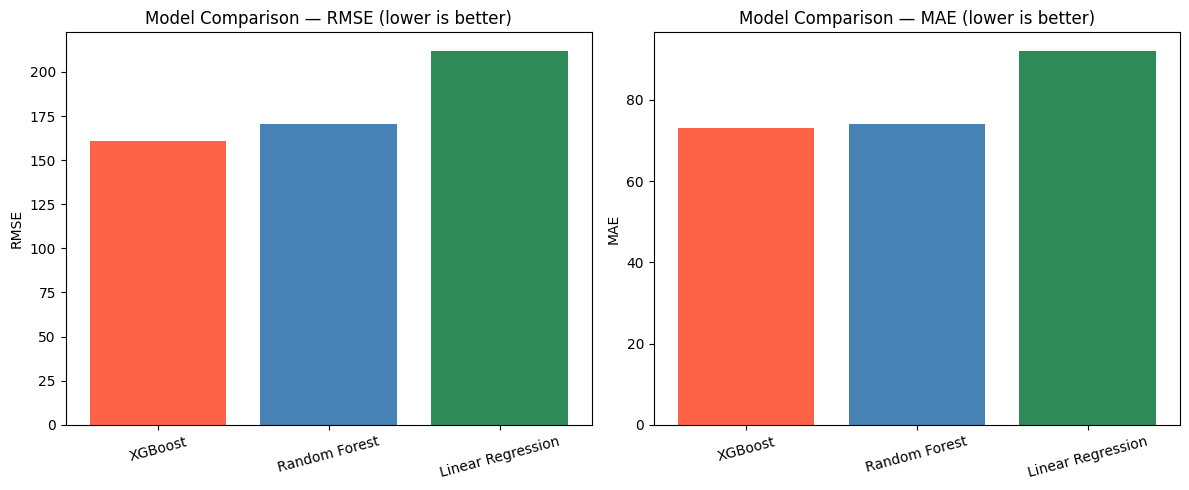

Saved: model_comparison.png ✅


In [ ]:
# Cell 9 — Model Comparison Table
print('=' * 55)
print('          MODEL COMPARISON — ALL METRICS')
print('=' * 55)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')
print(results_df.to_string(index=False))
best_model_name = results_df.iloc[0]['model']
print(f'\n🏆 Best Model: {best_model_name}')
print('=' * 55)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = results_df['model'].tolist()
colors = ['tomato', 'steelblue', 'seagreen']

axes[0].bar(models, results_df['RMSE'], color=colors)
axes[0].set_title('Model Comparison — RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(models, results_df['MAE'], color=colors)
axes[1].set_title('Model Comparison — MAE (lower is better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(path + 'model_comparison.png', dpi=150)
plt.show()
print('Saved: model_comparison.png ✅')

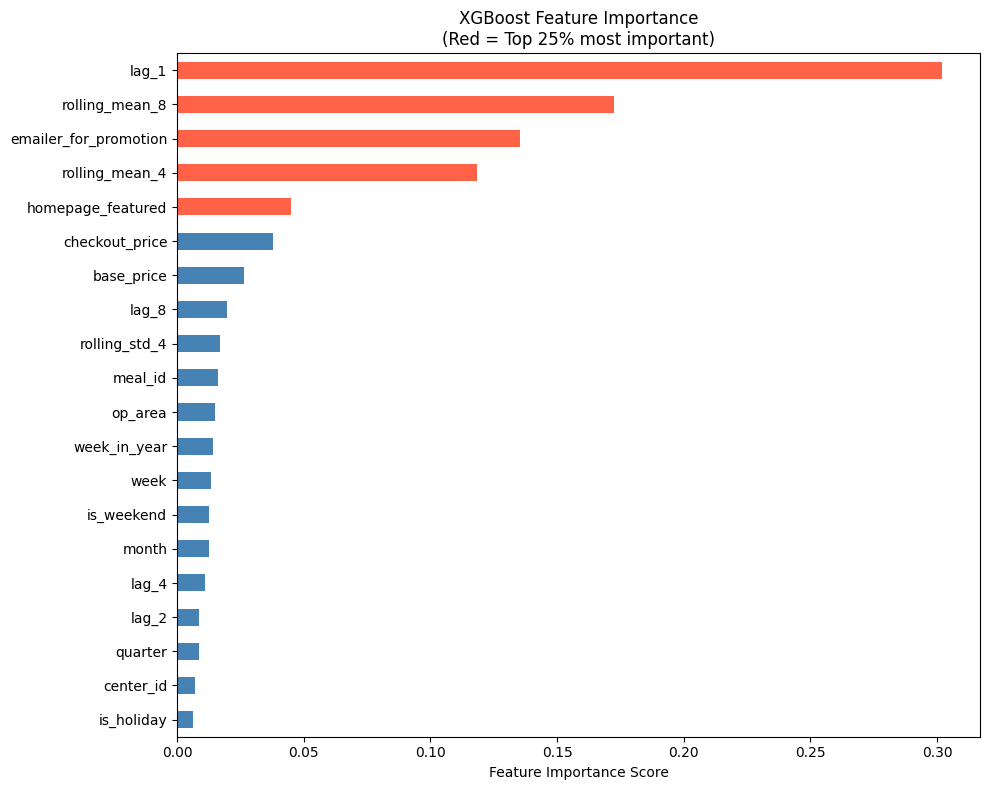

Saved: feature_importance.png ✅

Top 5 most important features:
lag_1                    0.301878
rolling_mean_8           0.172566
emailer_for_promotion    0.135487
rolling_mean_4           0.118585
homepage_featured        0.045085
dtype: float32


In [11]:
# Cell 10 — Feature Importance (XGBoost)
importance = pd.Series(
    xgb_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['tomato' if v > importance.quantile(0.75) else 'steelblue' for v in importance]
importance.plot(kind='barh', color=colors)
plt.xlabel('Feature Importance Score')
plt.title('XGBoost Feature Importance\n(Red = Top 25% most important)')
plt.tight_layout()
plt.savefig(path + 'feature_importance.png', dpi=150)
plt.show()

print('Saved: feature_importance.png ✅')
print('\nTop 5 most important features:')
print(importance.sort_values(ascending=False).head())

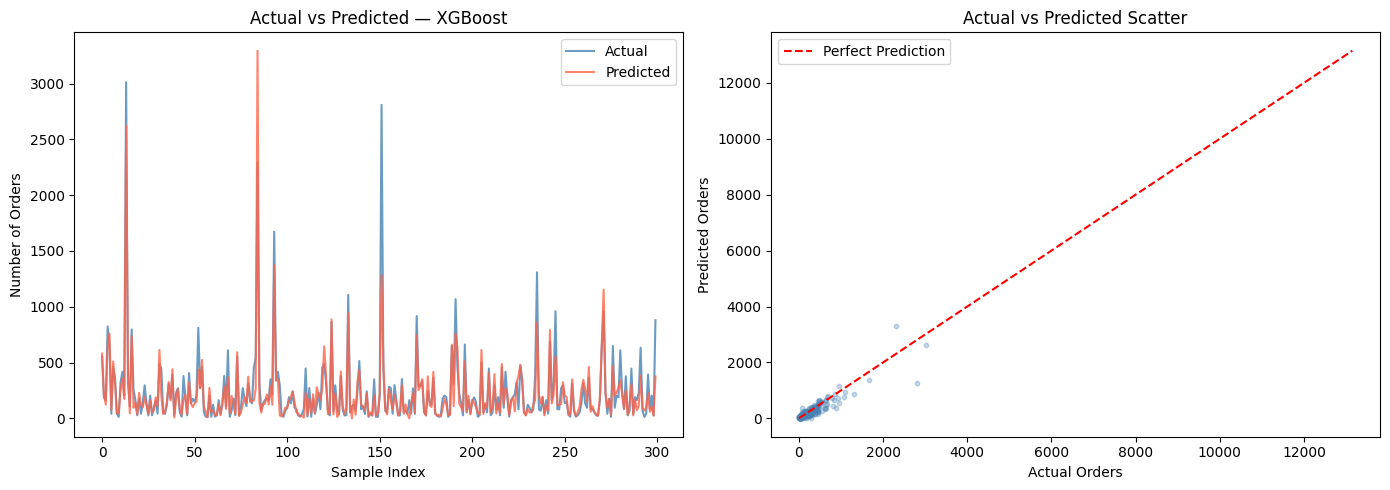

Saved: actual_vs_predicted.png ✅


In [12]:
# Cell 11 — Actual vs Predicted Plot (XGBoost — best model)
sample = min(300, len(y_test))
idx    = np.sort(np.random.choice(len(y_test), sample, replace=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot
axes[0].plot(y_test.values[idx],  label='Actual',    color='steelblue', alpha=0.8)
axes[0].plot(xgb_pred_test[idx],  label='Predicted', color='tomato',    alpha=0.8)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Actual vs Predicted — XGBoost')
axes[0].legend()

# Scatter plot
axes[1].scatter(y_test.values[idx], xgb_pred_test[idx], alpha=0.3, color='steelblue', s=10)
max_val = max(y_test.max(), xgb_pred_test.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
axes[1].set_xlabel('Actual Orders')
axes[1].set_ylabel('Predicted Orders')
axes[1].set_title('Actual vs Predicted Scatter')
axes[1].legend()

plt.tight_layout()
plt.savefig(path + 'actual_vs_predicted.png', dpi=150)
plt.show()
print('Saved: actual_vs_predicted.png ✅')

In [13]:
# Cell 12 — Save the best model (XGBoost)
model_path = path + 'xgboost_demand_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(xgb_final, f)

print(f'Best model saved: xgboost_demand_model.pkl ✅')
print('Note: .pkl excluded from GitHub via .gitignore (as per project guidelines)')

Best model saved: xgboost_demand_model.pkl ✅
Note: .pkl excluded from GitHub via .gitignore (as per project guidelines)


In [15]:
# Cell 13 — Week 3 Summary
xgb_res = results_df[results_df['model'] == 'XGBoost'].iloc[0]

print('=' * 55)
print('         WEEK 3 COMPLETE — SUMMARY')
print('=' * 55)
print()
print('Models Trained:')
print('  1. Linear Regression   → Baseline model')
print('  2. Random Forest       → Ensemble model')
print('  3. XGBoost             → Best model (winner)')
print()
print('Tuning Method : Time-Series Cross Validation (5 folds)')
print('No data leakage: future data never seen during training')
print()
print('Best Model (XGBoost) Test Results:')
print(f'  RMSE  : {xgb_res["RMSE"]:.2f}')
print(f'  MAE   : {xgb_res["MAE"]:.2f}')
print(f'  RMSLE : {xgb_res["RMSLE"]:.4f}')
print()
print('Outputs saved:')
print('  ✅ model_comparison.png')
print('  ✅ feature_importance.png')
print('  ✅ actual_vs_predicted.png')
print('  ✅ xgboost_demand_model.pkl (local only)')
print('=' * 55)

         WEEK 3 COMPLETE — SUMMARY

Models Trained:
  1. Linear Regression   → Baseline model
  2. Random Forest       → Ensemble model
  3. XGBoost             → Best model (winner)

Tuning Method : Time-Series Cross Validation (5 folds)
No data leakage: future data never seen during training

Best Model (XGBoost) Test Results:
  RMSE  : 160.82
  MAE   : 73.07
  RMSLE : 0.6716

Outputs saved:
  ✅ model_comparison.png
  ✅ feature_importance.png
  ✅ actual_vs_predicted.png
  ✅ xgboost_demand_model.pkl (local only)
